# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

### **Pima Indians Diabetes Database**

Dataset ini awalnya berasal dari **National Institute of Diabetes and Digestive and Kidney Diseases**. Tujuan utama dari eksperimen ini adalah untuk memprediksi secara diagnostik apakah seorang pasien mengidap penyakit diabetes atau tidak, berdasarkan beberapa variabel pengukuran medis yang disertakan.

* **Sumber Dataset:** [Diabetes Dataset di Kaggle](https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset)
* **Karakteristik Data:** Seluruh pasien dalam dataset ini adalah wanita berusia minimal 21 tahun yang memiliki garis keturunan suku Pima Indian.

#### **Daftar Fitur dan Target:**
1. **Pregnancies**: Jumlah kehamilan yang pernah dialami pasien.
2. **Glucose**: Tingkat konsentrasi glukosa dalam plasma darah (uji toleransi glukosa 2 jam).
3. **BloodPressure**: Tekanan darah diastolik (mm Hg).
4. **SkinThickness**: Ketebalan lipatan kulit trisep (mm).
5. **Insulin**: Kadar insulin serum 2 jam (mu U/ml).
6. **BMI**: Indeks Massa Tubuh (berat badan dalam kg / (tinggi dalam m)^2).
7. **DiabetesPedigreeFunction**: Indikator persentase riwayat genetik diabetes pada keluarga.
8. **Age**: Usia pasien (tahun).
9. **Outcome**: Variabel target (0 = Tidak Diabetes, 1 = Diabetes).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns_with_zero:
    zero_count = (df[column] == 0).sum()
    print(f"Jumlah nilai nol di kolom '{column}': {zero_count}")

Jumlah nilai nol di kolom 'Glucose': 5
Jumlah nilai nol di kolom 'BloodPressure': 35
Jumlah nilai nol di kolom 'SkinThickness': 227
Jumlah nilai nol di kolom 'Insulin': 374
Jumlah nilai nol di kolom 'BMI': 11


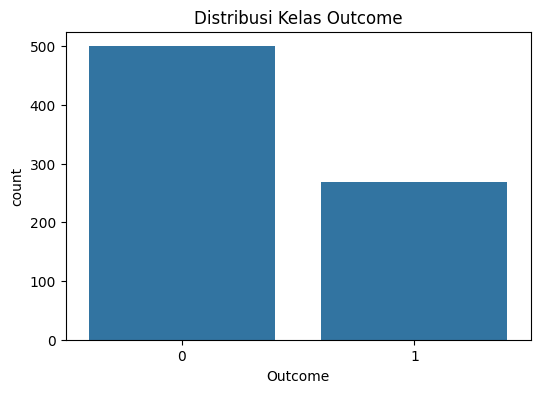

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Outcome')
plt.title('Distribusi Kelas Outcome')
plt.show()

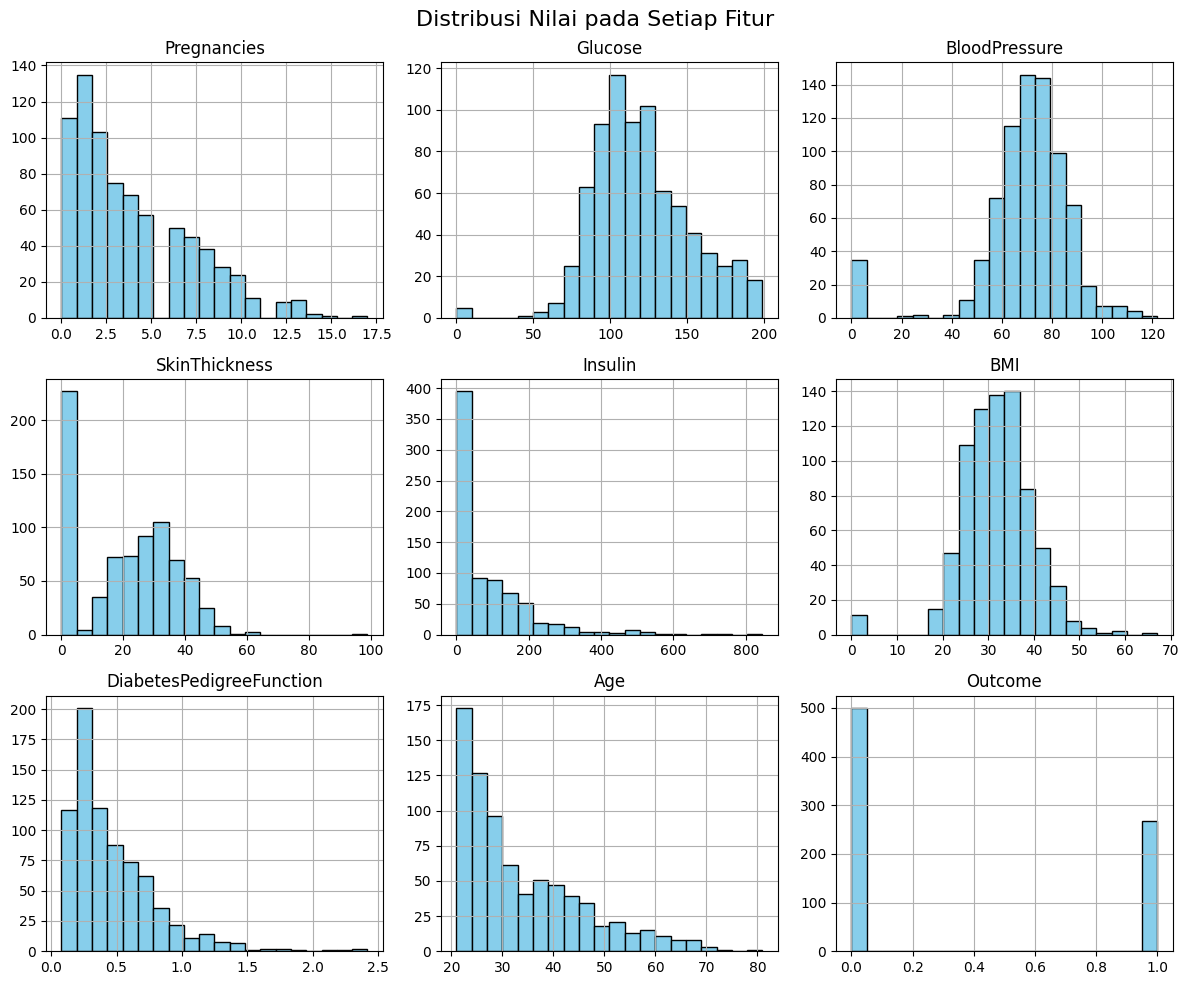

In [7]:
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Nilai pada Setiap Fitur', fontsize=16)
plt.tight_layout()
plt.show()

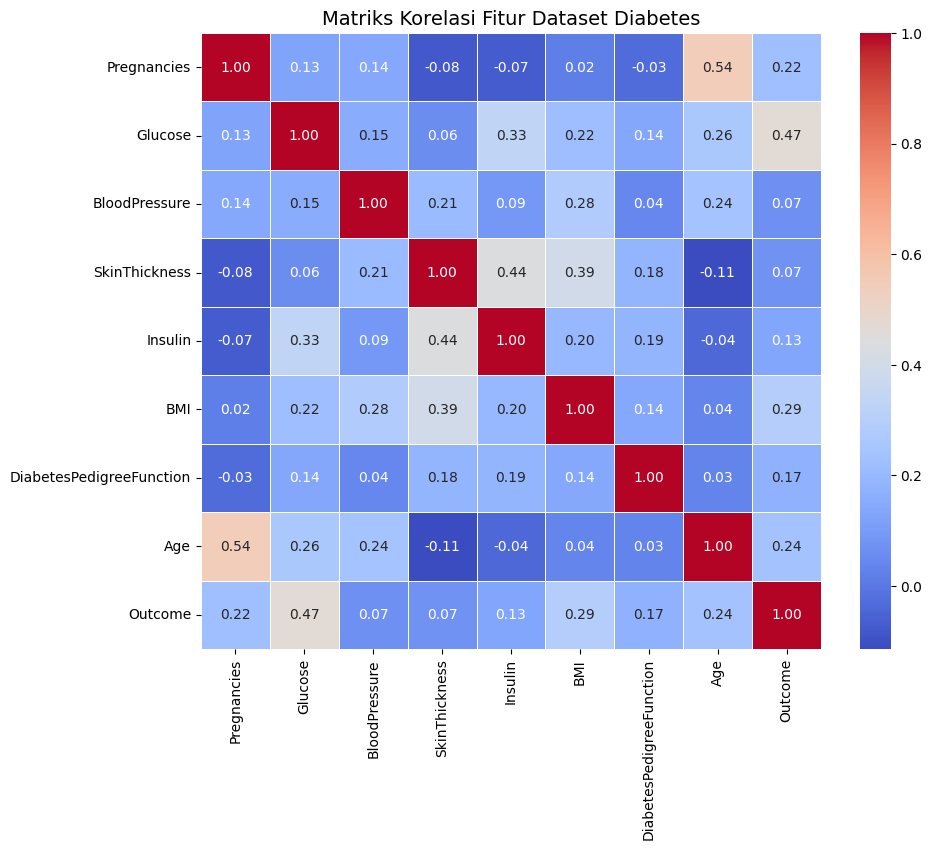

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Dataset Diabetes', fontsize=14)
plt.show()

/tmp/ipykernel_946/2630547554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='Glucose', palette='Set2')


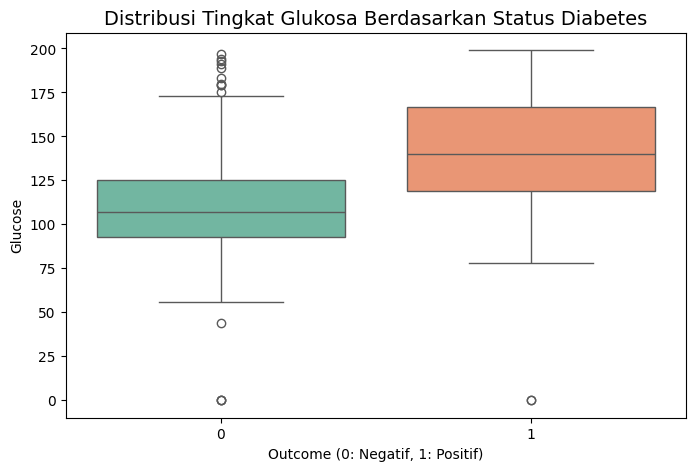

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Outcome', y='Glucose', palette='Set2')
plt.title('Distribusi Tingkat Glukosa Berdasarkan Status Diabetes', fontsize=14)
plt.xlabel('Outcome (0: Negatif, 1: Positif)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
for col in columns_with_zero:
  df[col] = df[col].replace(0, np.nan)
  df[col] = df[col].fillna(df[col].median())

In [11]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
output_dir = 'preprocessing/diabetes_dataset'
os.makedirs(output_dir, exist_ok=True)

In [14]:
train_processed = pd.DataFrame(X_train_scaled, columns=X.columns)
train_processed['Outcome'] = y_train.values

In [15]:
test_processed = pd.DataFrame(X_test_scaled, columns=X.columns)
test_processed['Outcome'] = y_test.values

In [16]:
train_processed.to_csv(f"{output_dir}/diabetes_train.csv", index=False)
test_processed.to_csv(f"{output_dir}/diabetes_test.csv", index=False)

print("Preprocessing done")

Preprocessing done
